In [ ]:
from firedrake import *
import numpy as np
import matplotlib.pyplot as plt

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


# Ex.1 - Stokes: patch test on Coutte flow

\begin{equation*}
\begin{cases}
- \Delta \boldsymbol{u} + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega=(0,3)\times(0,1), \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, \\
(\nabla\boldsymbol{u}-pI)\boldsymbol{n} = \boldsymbol{0} & {\rm on} \ \Gamma_1\cup\Gamma_2,\\
\boldsymbol{u} = \boldsymbol{0} & {\rm on} \ \Gamma_3, \\
\boldsymbol{u} = \boldsymbol{g}_\text{D} & {\rm on} \ \Gamma_4.
\end{cases}
\end{equation*}

with $\boldsymbol{g}_\text{D} = 1\boldsymbol{i}$.

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


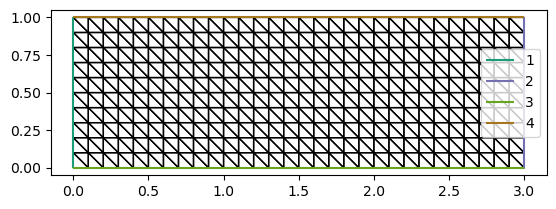

In [81]:
# Rectangle mesh

N = 10
mesh = RectangleMesh(3*N, N, 3.0, 1.0, diagonal='left')
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend()
ax.set_aspect("equal")

In [ ]:
# Stokes problem

# Define function space and trial/test functions for velocity and pressure
V = VectorFunctionSpace(mesh, "P", 2)
Q = FunctionSpace(mesh, "P", 1)
W = MixedFunctionSpace([V, Q])
u, p = TrialFunctions(W)
v, q = TestFunctions(W)
print('\nNumber of DOF \n - u    :',V.dim(),' \n - p    :',Q.dim(),' \n - total:',W.dim())

# Other choices of function spaces:

# P1-P0
# V = VectorFunctionSpace(mesh, 'P', 1)
# Q = FunctionSpace(mesh, 'DP', 0) # NB: P0 are DISCONTINUOUS elements (DP)

# # P1-P1
# V = VectorFunctionSpace(mesh, 'P', 1)
# Q = FunctionSpace(mesh, 'P', 1)

# # P1b-P1
# # The enrichment of the velocity space has to be done at the finite element level
# V1_el = FiniteElement('CG', mesh.ufl_cell(), 1)
# B_el = FiniteElement('Bubble', mesh.ufl_cell(), mesh.topological_dimension + 1)
# V_el = VectorElement(NodalEnrichedElement(V1_el, B_el))
# V = FunctionSpace(mesh, V_el)
# Q = FunctionSpace(mesh, 'P', 1)

# Define boundary conditions for velocity (Dirichlet BCs)
bcs = [DirichletBC(W.sub(0), Constant((0.0, 0.0)), 3), # Bottom boundary
       DirichletBC(W.sub(0), Constant((1.0, 0.0)), 4) # Top boundary
       ]

# Define the variational problem
a = inner(grad(u), grad(v)) * dx - p * div(v) * dx + q * div(u) * dx
L = inner(Constant((0.0, 0.0)), v) * dx

# Solve the problem
w_h = Function(W)
solve(a == L, w_h, bcs=bcs)

Text(0.5, 1.0, 'Pressure field')

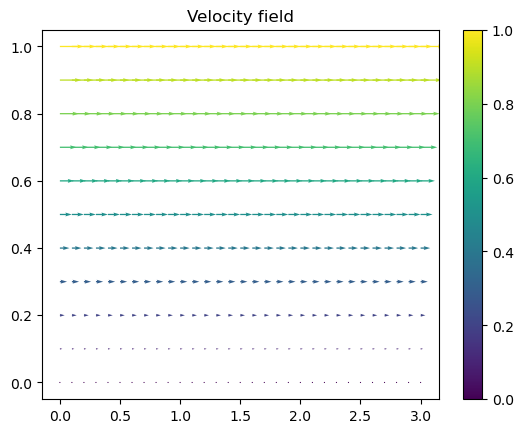

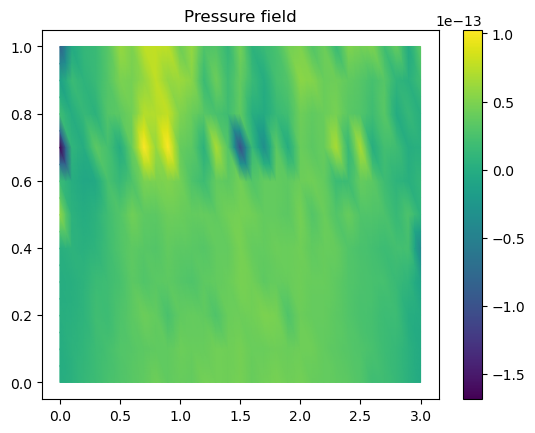

In [83]:
# Plot velocity and pressure
u_h, p_h = w_h.subfunctions

fig, ax = plt.subplots()
q = quiver(u_h, axes=ax)
fig.colorbar(q)
ax.set_title("Velocity field")

fig, ax = plt.subplots()
q = tripcolor(p_h, axes=ax)
fig.colorbar(q)
ax.set_title("Pressure field")

In [ ]:
# Compute the H1 error (compering with the exact solution u = (y, 0))
x = SpatialCoordinate(mesh)
u_ex = Function(V)
u_ex.interpolate(as_vector([x[1], 0.0]))
grad_u_ex = as_tensor([[0.,1.],[0.,0.]])
print(f"||u-u_h||_L2          : {errornorm(u_ex, u_h, norm_type="L2"):.6e}")
print(f"||u-u_h||_H1          : {errornorm(u_ex, u_h, norm_type="H1"):.6e}")
errH10u = sqrt(assemble(inner(grad(u_h)-grad_u_ex,grad(u_h)-grad_u_ex) * dx ))
print(f"||u-u_h||_H1 semi-norm error: {errH10u:.6e}")

p_ex = Function(Q)
p_ex.interpolate(Constant(0.0))
print(f"||p-p_h||_L2          : {errornorm(p_ex, p_h, norm_type="L2"):.6e}")
print('\nNumber of DOF \n - u    :',V.dim(),' \n - p    :',Q.dim(),' \n - total:',W.dim())

Velocity L2 error          : 8.037346e-15
Velocity H1 error          : 3.467958e-14
Velocity H1 semi-norm error: 3.227182e-14
Pressure L2 error          : 6.018923e-14

Number of DOF 
 - u    : 2562  
 - p    : 341  
 - total: 2903


# Ex.2 - Stokes: algebraic formulation for Poiseuille flow

\begin{equation*}
\begin{cases}
- \mu\Delta \boldsymbol{u} + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega=(0,2)\times(-1,1), \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, \\
\boldsymbol{u} = \boldsymbol{0} & {\rm on} \ \Gamma_\text{wall}=\{0\leq x\leq2, y\in\{-1,1\}\}, \\
\boldsymbol{u} = \boldsymbol{g}_\text{D} & {\rm on} \ \Gamma_\text{in}=\{x=0,-1\leq y\leq 1\},\\
(\nabla\boldsymbol{u}-pI)\boldsymbol{n} = \boldsymbol{0} & {\rm on} \ \Gamma_\text{out}=\{x=2,-1\leq y\leq 1\},\\
\end{cases}
\end{equation*}

with $\mu=10^{-2}$ and $\boldsymbol{g}_\text{D} = (1-y^2)\boldsymbol{i}$.

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


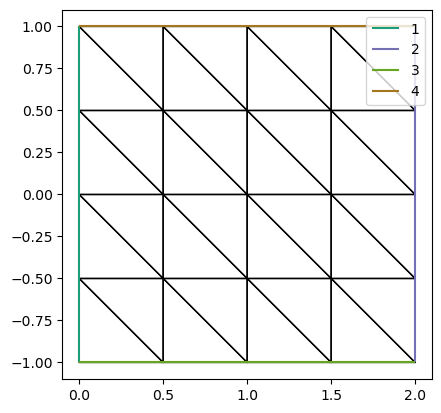

In [ ]:
# Rectangle mesh

N = 4
mesh = RectangleMesh(N, N, 2.0, 1.0, originY=-1, diagonal='left')
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend()
ax.set_aspect("equal")

In [76]:
# Stokes problem

# Define function space and trial/test functions for velocity and pressure
V = VectorFunctionSpace(mesh, "P", 2)
Q = FunctionSpace(mesh, "P", 1)
W = MixedFunctionSpace([V, Q])
u, p = TrialFunctions(W)
v, q = TestFunctions(W)

# Other choices of function spaces:

# P1-P0
# V = VectorFunctionSpace(mesh, 'P', 1)
# Q = FunctionSpace(mesh, 'DP', 0) # NB: P0 are DISCONTINUOUS elements (DP)

# # P1-P1
# V = VectorFunctionSpace(mesh, 'P', 1)
# Q = FunctionSpace(mesh, 'P', 1)

# # P1b-P1
# # The enrichment of the velocity space has to be done at the finite element level
# V1_el = FiniteElement('CG', mesh.ufl_cell(), 1)
# B_el = FiniteElement('Bubble', mesh.ufl_cell(), mesh.topological_dimension + 1)
# V_el = VectorElement(NodalEnrichedElement(V1_el, B_el))
# V = FunctionSpace(mesh, V_el)
# Q = FunctionSpace(mesh, 'P', 1)

# Define boundary conditions for velocity (Dirichlet BCs)
x = SpatialCoordinate(mesh)
bcs = [
       DirichletBC(W.sub(0), (1 - x[1]**2, 0.0), 1), # Left boundary
       DirichletBC(W.sub(0), Constant((0.0, 0.0)), 3), # Bottom boundary
       DirichletBC(W.sub(0), Constant((0.0, 0.0)), 4) # Top boundary
       ]

# Define the variational problem
mu = Constant(1e-2)
a = mu * inner(grad(u), grad(v)) * dx - p * div(v) * dx + q * div(u) * dx
L = inner(Constant((0.0, 0.0)), v) * dx

# Solve the problem
w_h = Function(W)
parameters = {'ksp_type': 'preonly', "pc_type": "lu", "pc_factor_mat_solver_type": "mumps"}
solve(a == L, w_h, bcs=bcs, solver_parameters=parameters)

Text(0.5, 1.0, 'Pressure field')

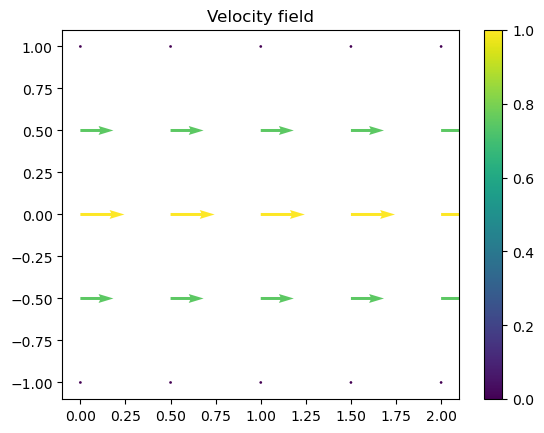

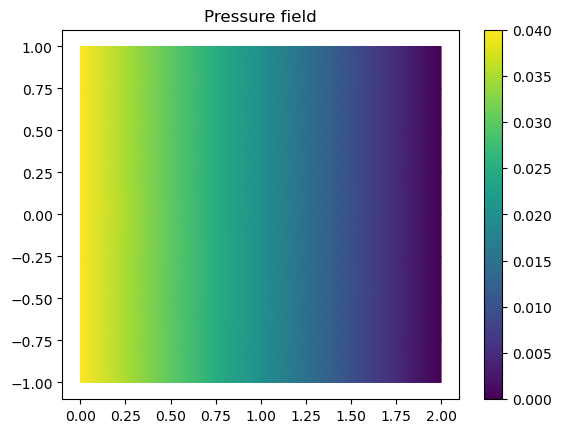

In [77]:
# Plot velocity and pressure
u_h, p_h = w_h.subfunctions

fig, ax = plt.subplots()
q = quiver(u_h, axes=ax)
fig.colorbar(q)
ax.set_title("Velocity field")

fig, ax = plt.subplots()
q = tripcolor(p_h, axes=ax)
fig.colorbar(q)
ax.set_title("Pressure field")

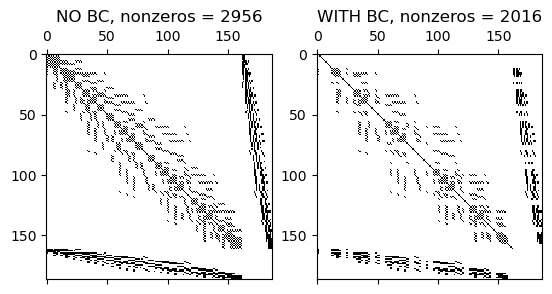

In [78]:
# Matrix inspection

# from Firedrake Matrix object (output of assemble of bilinear form) to numpy array
def mat2numpy(A):
  return A.petscmat.getValues(range(0, A.petscmat.getSize()[0]), range(0,  A.petscmat.getSize()[1]))

fig, (ax1, ax2) = plt.subplots(1, 2)
A = assemble(a)
Anumpy = mat2numpy(A)
ax1.spy(Anumpy)
ax1.title.set_text('NO BC, nonzeros = '+str(np.count_nonzero(Anumpy)))
A = assemble(a, bcs=bcs)
Anumpy = mat2numpy(A)
ax2.spy(Anumpy)
ax2.title.set_text('WITH BC, nonzeros = '+str(np.count_nonzero(Anumpy)))

# Additional Ex. Stokes: Null space for fully Dirichlet bc

\begin{equation*}
\begin{cases}
- \Delta \boldsymbol{u} + \nabla  p  = \boldsymbol{f} & {\rm in} \ \Omega=(0,1)\times(0,1), \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, \\
\boldsymbol{u} = \boldsymbol{g}_\text{D} & {\rm on} \ \partial \Omega.
\end{cases}
\end{equation*}

with $\boldsymbol{g}_\text{D}$ such that the velocity is

$$
u(x,y)=
\begin{pmatrix}
-\cos(x)\sin(y)\\
\sin(x)\cos(y)
\end{pmatrix}
$$

and the pressure is

$$
p(x,y)
=
-\frac14\left(\cos(2x)+\cos(2y)\right)
+\frac14\sin(2).
$$

Consequentely, we also must have

$$
f=
\begin{pmatrix}
-2\cos(x)\sin(y)+\frac12\sin(2x)\\[6pt]
2\sin(x)\cos(y)+\frac12\sin(2y)
\end{pmatrix}.
$$

We observe that the null space of the resulting matrix (with Dirichlet conditions!)

$$
\Sigma = \begin{bmatrix}
A & B^T \\
B & 0
\end{bmatrix}
$$

has dimension equal to one, since translations of the pressure are allowed. We compute the null space and observe that it is one-dimensional and given by the span of

$$
\begin{bmatrix}
0 \\
1
\end{bmatrix},
$$
i.e. the space of zero velocity and constant pressure.

firedrake:WARNING No comm specified for VectorSpaceBasis, COMM_WORLD assumed


Dimension of the computed nullspace :  1
4 smallest eigenvalues              :  [1.35577776e-16 3.93640421e-04 4.08702846e-04 1.32844375e-03]


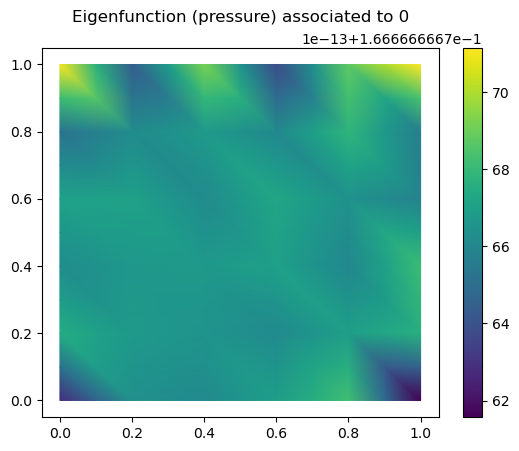

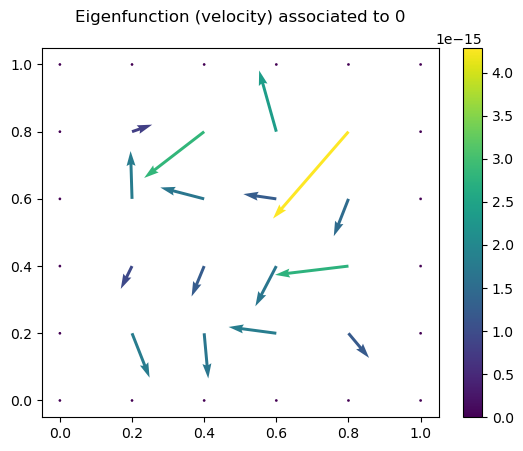

In [ ]:
# Exact solution
u_ex_fun = lambda x: as_vector((
    -cos(x[0]) * sin(x[1]),
    sin(x[0]) * cos(x[1])))
p_ex_fun = lambda x: -0.25 * (cos(2*x[0]) + cos(2*x[1])) + 0.25*sin(2.0)
f_fun = lambda x: as_vector((
    -2 * cos(x[0]) * sin(x[1]) + 0.5 * sin(2 * x[0]),
    2 * sin(x[0]) * cos(x[1]) + 0.5 * sin(2 * x[1])))

# Define the mesh
N=5
mesh = UnitSquareMesh(N, N, 'crossed')

# Define the function spaces
V = VectorFunctionSpace(mesh, 'P', 2)
Q = FunctionSpace(mesh, 'P', 1)
W = MixedFunctionSpace([V, Q])

# Define boundary conditions for velocity (Dirichlet BCs)
x = SpatialCoordinate(mesh)
gD = u_ex_fun(x)
bc = DirichletBC(W.sub(0), gD, 'on_boundary')

# Define trial and test functions
u, p = TrialFunctions(W)
v, q = TestFunctions(W)

# Define the force term
f = f_fun(x)

# Define the variational problem
a = inner(grad(u), grad(v)) * dx - div(v) * p * dx + q * div(u) * dx

# Monolithic matrix in numpy format
Sigma = assemble(a, bcs=(bc)).M.values

# Compute eigenvalues and eigenvectors of the monolithic matrix
w, vv = np.linalg.eig(Sigma)

# Find the nullspace of the monolithic matrix (eigenvectors associated to eigenvalue "0")
true_nullspace = vv[:, abs(w)<1e-14]
print('Dimension of the computed nullspace : ', true_nullspace.shape[1])
sorted_w = np.sort(w)
print('4 smallest eigenvalues              : ', sorted_w[0:4])

# Pick the last Qdim entries, i.e. the ones associated to the pressure space
Qdim = Q.dim()
ps = Function(Q, val=true_nullspace[-Qdim:,0])

# Plot eigenmode
fig, ax = plt.subplots()
q = tripcolor(ps, axes=ax)
plt.colorbar(q)
plt.title('Eigenfunction (pressure) associated to 0\n')

# Pick the first Vdim entries, i.e. the ones associated to the pressure space
Vdim = V.dim()
us = Function(V, val=true_nullspace[:Vdim,0])

# Plot eigenmode
fig, ax = plt.subplots()
q = quiver(us, axes=ax)
plt.colorbar(q)
plt.title('Eigenfunction (velocity) associated to 0\n')